In [178]:
import sys, os, importlib
package_path = os.path.abspath('../../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

# set seed for reproducibility
np.random.seed(2026)

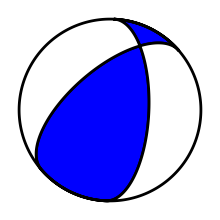

In [179]:
from pyrocko.plot import beachball
import matplotlib.pyplot as plt

# strike, dip, rake
t, p = fn.i_hat, fn.k_hat

# generate synthetic data
t = fn.unit_vec(np.random.rand(3))
direc = fn.unit_vec(np.random.rand(3))
p = fn.starting_direc(t, direc)

sdr = fn.tp2sdr(t, p, True)[0]

# plot corresponding beachball
enu_mt = fn.tp2mt(t, p)
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])
my_ball = fn.beachball(comp_mt)

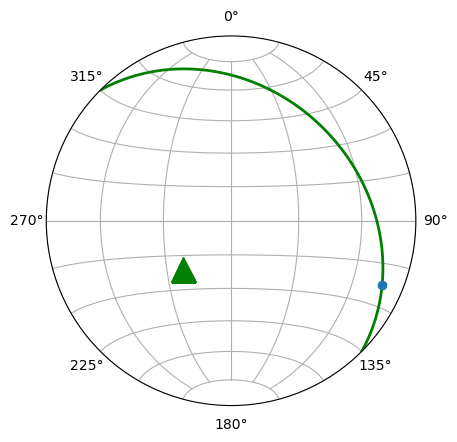

In [180]:
import matplotlib.pyplot as plt
import mplstereonet

fig = plt.figure()
ax = fig.add_subplot(111, projection='stereonet')

strike, dip = 315, 30
ax.plane(strike, dip, 'g-', linewidth=2)
ax.pole(strike, dip, 'g^', markersize=18)
ax.rake(strike, dip, -25)
ax.grid()

plt.show()

Original params:  [333   8 118]


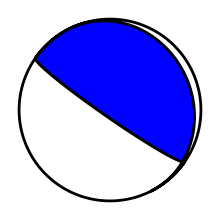

In [181]:
np.random.seed(2025)

# get true params for synthetic test
benchmark = (np.array([333, 8, 118]), np.array([125, 83, 86]))
# benchmark = (np.array([132, 79, 170]), np.array([224, 80, 12]))
true_params = benchmark[0]
print('Original params: ', true_params)

# # generate synthetic data
# t = fn.unit_vec(np.random.rand(3))
# t = fn.unit_vec(fn.j_hat + fn.k_hat)
# direc = fn.unit_vec(np.random.rand(3))
# p = fn.starting_direc(t, direc)
# p = fn.unit_vec(-fn.j_hat + fn.k_hat)
# true_params = fn.tp2sdr(t, p, True)[0]
# print('Original params: ', true_params)

t, p = fn.sdr2tp(true_params, deg=True)
enu_mt = fn.tp2mt(t, p)
mt = enu_mt
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])

# plot corresponding beachball
# beachball = fn.beachball(true_params)
beachball = fn.beachball(comp_mt)

# velocity model, assume depth, vp and vs cols
velocity_model = TauPyModel(model='ak135')
data_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(data_path)

In [182]:
# parse a string and get its sum
import numpy as np
str = '221201101102202122101'
np.array(list(str)).astype(int).sum()

24

In [183]:
eq_lat = 2.0964
eq_lon = 97.1131
hdepth = 30.0  # km

# eq_lat = 45.425
# eq_lon = 16.2581
# hdepth = 12.0  # km

In [184]:
velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

At depth 30.0 km, P velocity = 6.5 km/s, S velocity = 3.85 km/s


In [185]:
# unc = (3.1275938939507688e-06, 5.329208956669851e-05, 5.591222696695143e-05)
# unc = np.array(unc)
# unc

unc = (1.5935813127232e-07, 7.688377642526138e-07, 9.845371528736786e-07)
unc = np.array(unc)
unc

array([0., 0., 0.])

In [186]:
# where did I get these uncertainties from?

In [187]:
# set up hyperparameters for inversion
epdist_1 = 39.72  # degrees - epicentral distance
azimuth_1 = 153.06  # degrees - azimuth of seismometer

# epdist_1 = 44.33 #  # degrees - epicentral distance
# azimuth_1 = 63.49 #   # degrees - azimuth of seismometer

p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_1, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist_1, phase_list=['S'])
takeoff_angles = [p_arrivals[0].takeoff_angle, s_arrivals[0].takeoff_angle]
velocities = fn.extract_velocities(lookup_table, hdepth)

# initialize model
radiation_model_1 = rm.RadiationModel(np.deg2rad(azimuth_1), takeoff_angles, velocities)

model_Ao1 = radiation_model_1(np.deg2rad(true_params), set_Ao=True, return_A=True)
print('Original Ao: ', model_Ao1)
takeoff_angles

Original Ao:  [-0.0008  0.0056 -0.0133]


[29.243322228895718, 31.420692688458985]

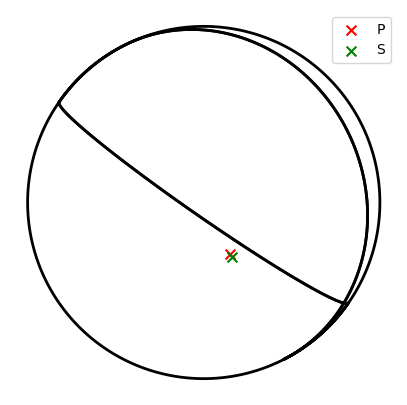

In [188]:
import matplotlib.pyplot as plt
from obspy.imaging.beachball import beach

fig, ax = plt.subplots(figsize=(5,5))

# Example moment tensor
enu_mt = fn.tp2mt(t, p)
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])

b = beach(comp_mt, facecolor='b', bgcolor='w', edgecolor='k', nofill=True)
ax.add_collection(b)

# escape point coordinates
# toff_mean = np.mean(takeoff_angles)
azimuth = azimuth_1
r1 = 100 * takeoff_angles[0]/90
r2 = 100 * takeoff_angles[1]/90
x1 = r1 * np.sin(np.deg2rad(azimuth))
y1 = r1 * np.cos(np.deg2rad(azimuth))
x2 = r2 * np.sin(np.deg2rad(azimuth))
y2 = r2 * np.cos(np.deg2rad(azimuth))

ax.scatter(x1, y1, color='red', s=50, marker='x', label='P')
ax.scatter(x2, y2, color='green', s=50, marker='x', label='S')
ax.legend(loc='upper right')

# hide axes
ax.set_axis_off()

plt.axis('equal')
plt.show()

In [189]:
# now set up a grid based on rotations around each axis

# function to set up rotation
Z_axis = fn.k_hat
N_axis = fn.j_hat
E_axis = fn.i_hat

true_t, true_p = fn.sdr2tp(true_params, deg=True)
print(true_t, true_p)

rotation_gap = 30  # degrees
thetas = np.arange(0, 360, rotation_gap)
thetas

new_ts = []
new_ps = []
new_sdrs = []
new_Aos = []

for theta in thetas:
    new_t = fn.rotate_vec (true_t, Z_axis, np.deg2rad(theta))
    new_p = fn.rotate_vec (true_p, Z_axis, np.deg2rad(theta))
    new_sdr = fn.tp2sdr(new_t, new_p, deg=True)[0]
    new_Ao = radiation_model_1(np.deg2rad(true_params), return_A=True)
    new_Aos.append(new_Ao)

[-0.3125 -0.5318  0.7871] [0.4879 0.6211 0.6133]


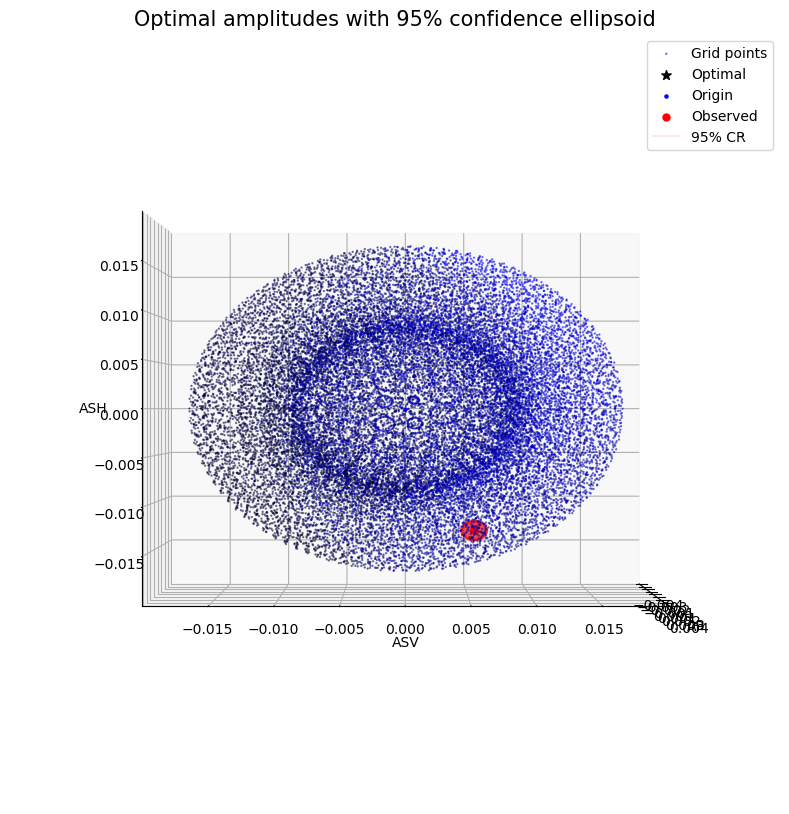

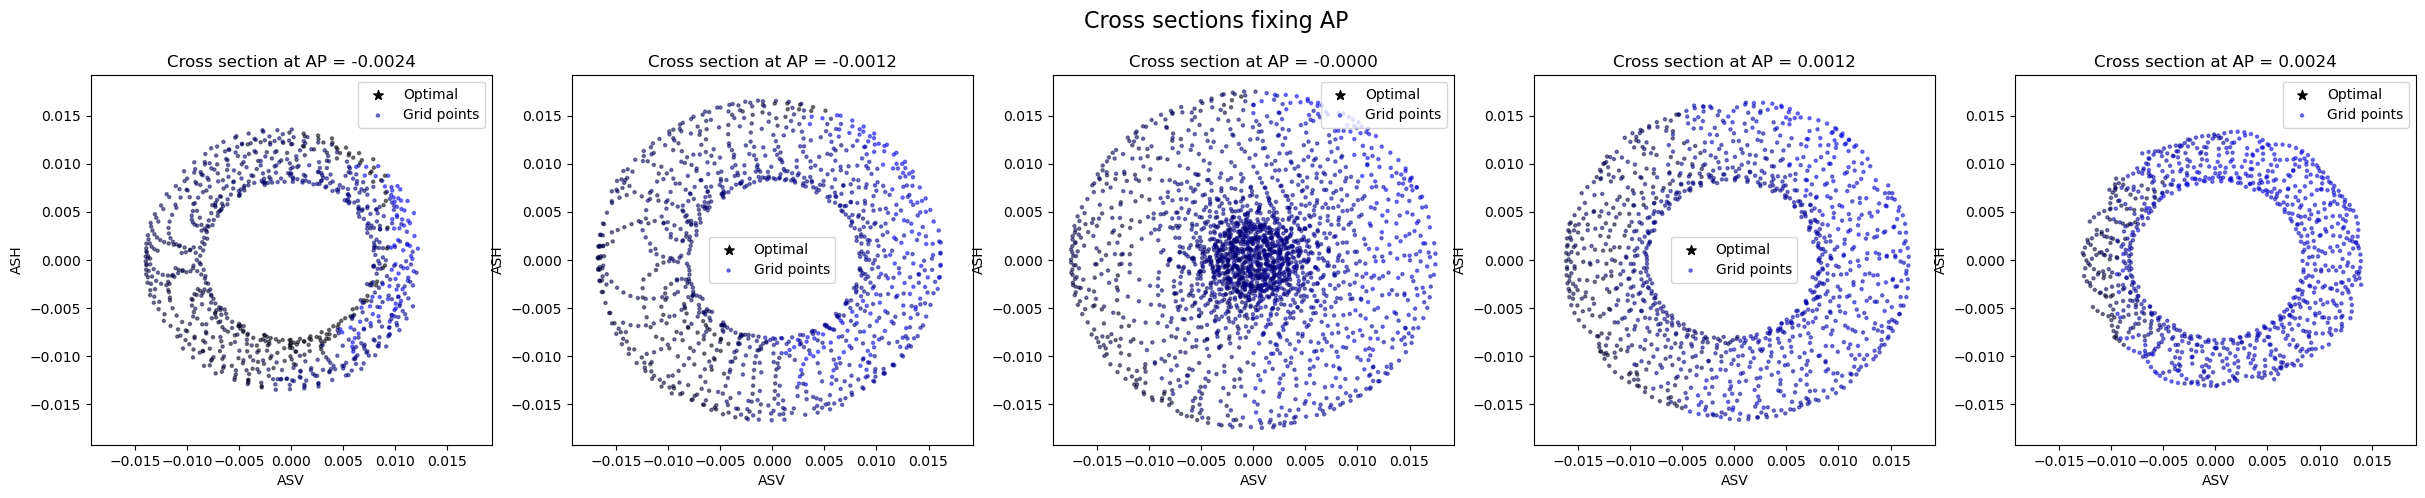

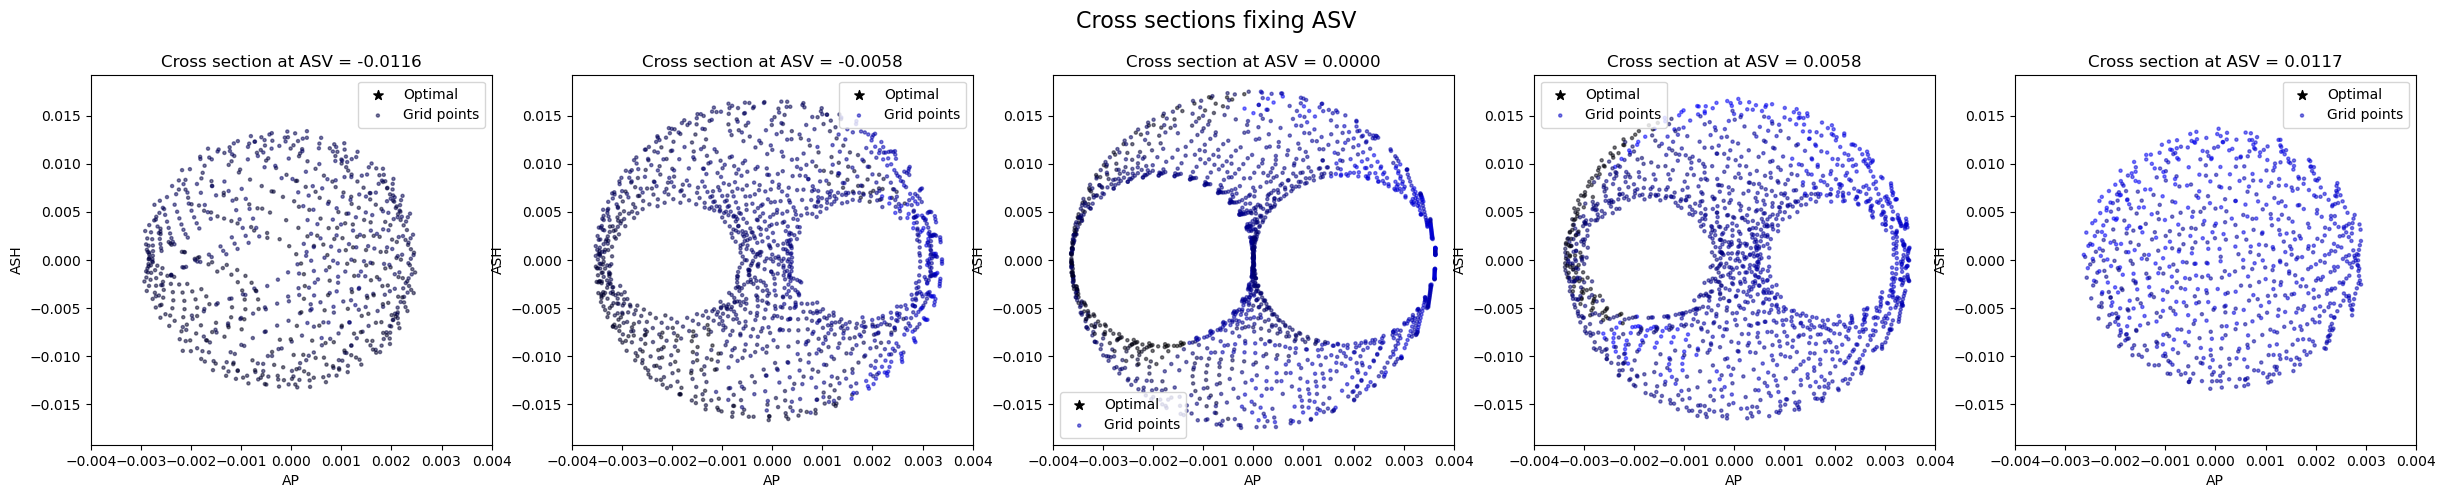

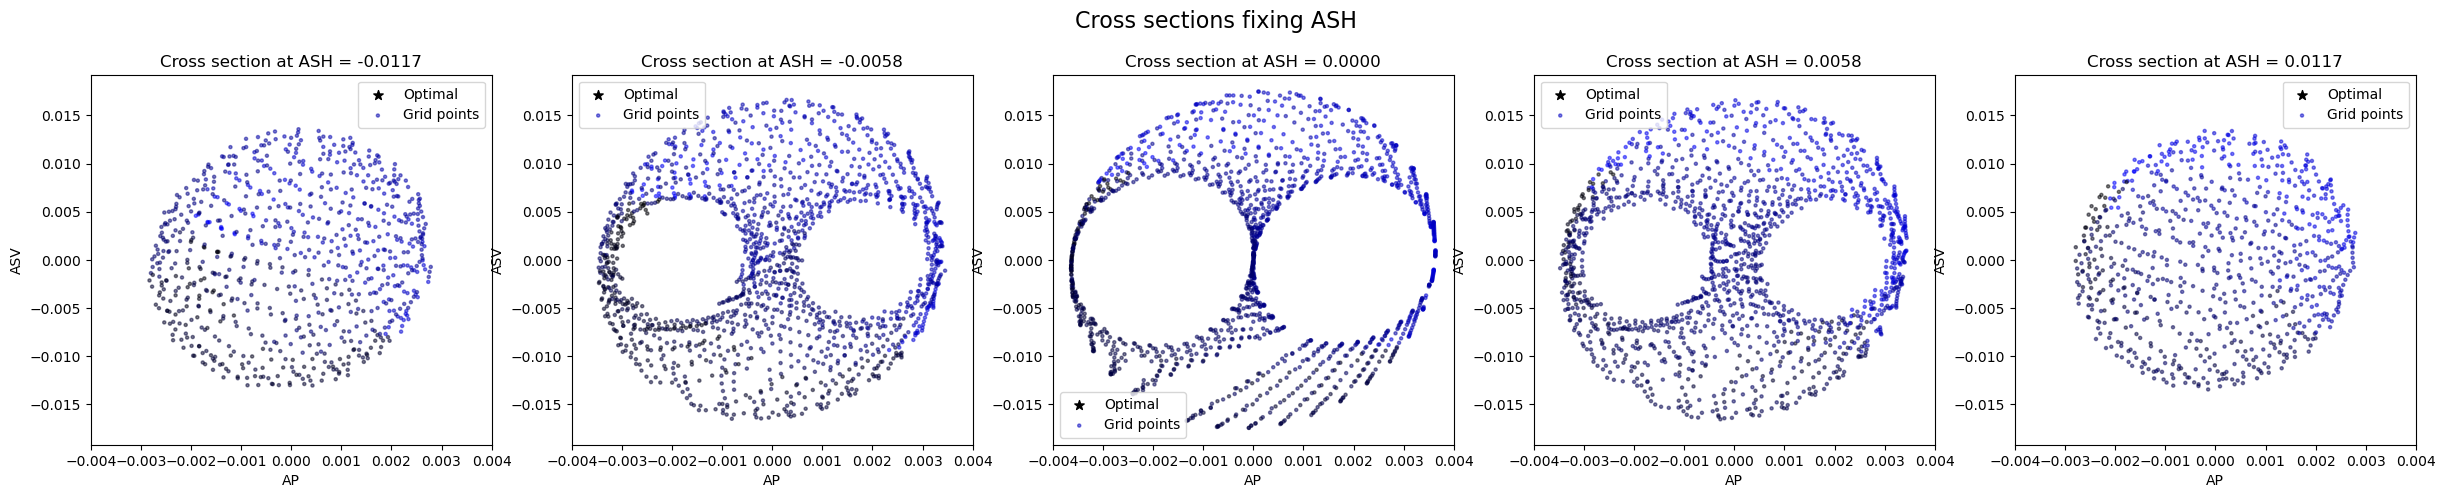

In [190]:
# RGB = strike, dip, rake
importlib.reload(plots)
radiation_model_1.reset_grid_amplitudes()
dd = 5
radiation_model_1.set_grid_amplitudes(dd, random=False, fix_params=False,
                                        zne=False)
plots.amplitudes(radiation_model_1, azim=0, elev=0, s=50, alpha=1,
                 iterates=False, grid=True, cross_section=[5,5,5],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                  uncertainty=True, conf=0.95, grid_mask=[0,0,1])

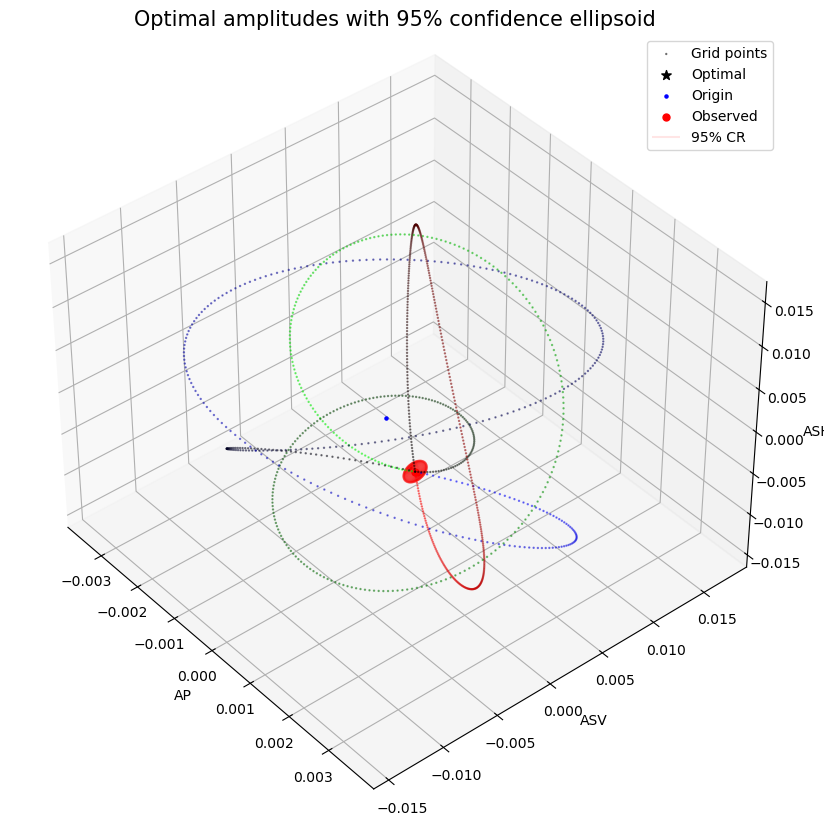

In [191]:
# I can modify the current function to color by azimuth or something
importlib.reload(plots)
radiation_model_1.reset_grid_amplitudes()
dd = 1
radiation_model_1.set_grid_amplitudes(dd, random=False, fix_params=True,
                                        zne=True)
plots.amplitudes(radiation_model_1, azim=-40, elev=40, s=50, alpha=1,
                 iterates=False, grid=True, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                  uncertainty=True, conf=0.95, grid_mask=[1,1,1])

(360, 9)


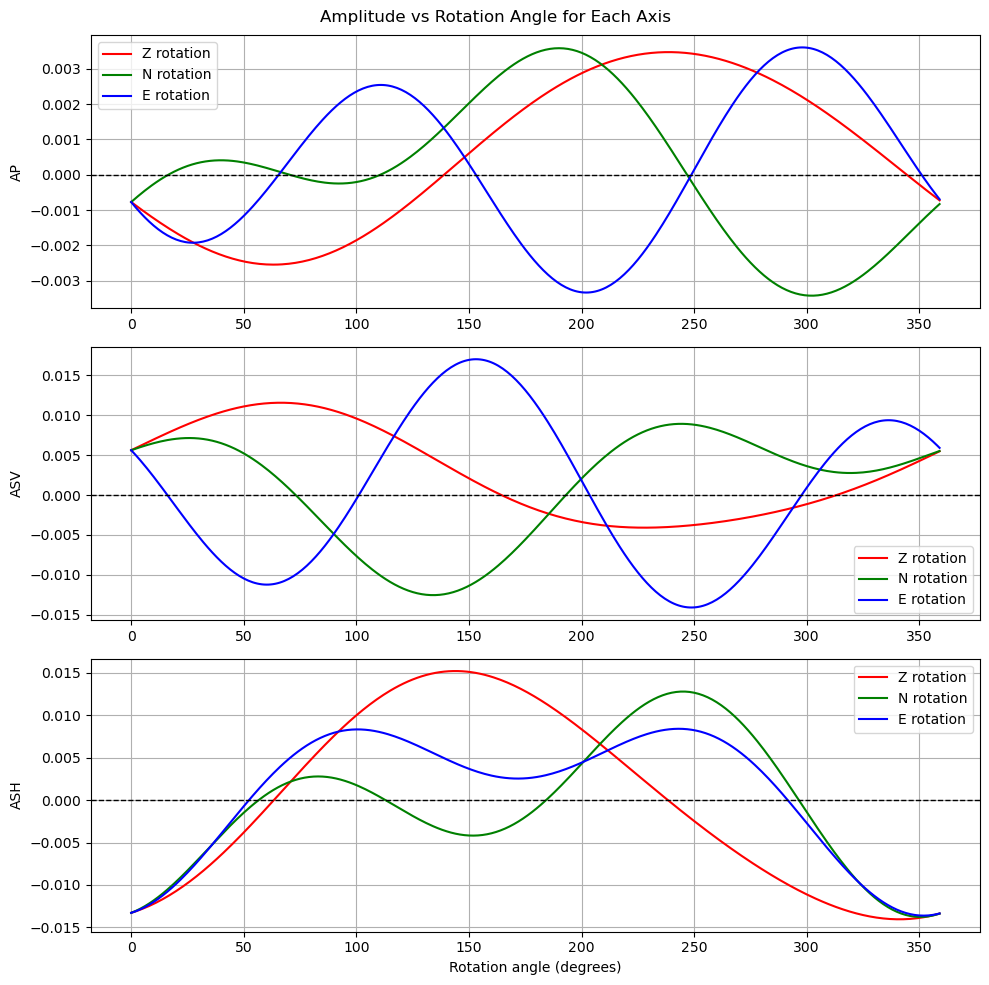

In [192]:
amps = np.array(radiation_model_1.get_grid_amplitudes())

# Z, N and E splits are 0, 1, 2 mod 3 indices respectively
Z_amps = amps[0::3]
N_amps = amps[1::3]
E_amps = amps[2::3]

new_matrix = np.column_stack((Z_amps, N_amps, E_amps))
print(new_matrix.shape)

# make line plots for [0-360] range of angles
angles = np.arange(0, 360, dd)

# make 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
amp_names = ['AP', 'ASV', 'ASH']

for i, name in enumerate(amp_names):
    # get the 0, 3, 6...
    Z_amp = Z_amps[:,i]
    N_amp = N_amps[:,i]
    E_amp = E_amps[:,i]
    axes[i].plot(angles, Z_amp, label='Z rotation', color='r')
    axes[i].plot(angles, N_amp, label='N rotation', color='g')
    axes[i].plot(angles, E_amp, label='E rotation', color='b')
    axes[i].set_ylabel(f'{amp_names[i]}')
    # horizontal line thru 0
    axes[i].axhline(0, color='k', linestyle='--', linewidth=1)
    axes[i].grid()
    axes[i].legend()

axes[-1].set_xlabel('Rotation angle (degrees)')
plt.suptitle('Amplitude vs Rotation Angle for Each Axis')
plt.tight_layout()
plt.show()

In [193]:
np.array([1,0,0]) * (1 - angles/360)[:, np.newaxis]
radiation_model_1.get_Ao()

array([-0.0008,  0.0056, -0.0133])

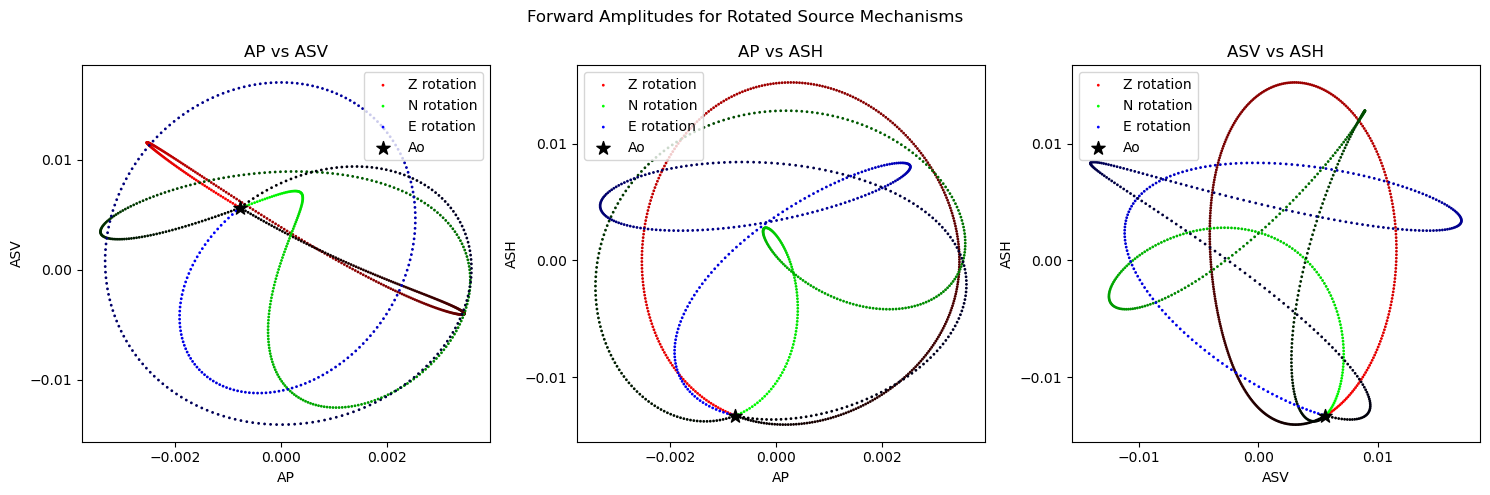

Max amplitudes:  [0.0036 0.017  0.0152]
Min amplitudes:  [-0.0034 -0.0141 -0.014 ]


In [194]:
data = np.array(radiation_model_1.get_grid_amplitudes())
colors = ['r', 'g', 'b'] * (len(data)//3)
labels = ['Z rotation', 'N rotation', 'E rotation']
angles = np.arange(0, 360, dd) # USE THIS FOR HOW BLACK IT IS in RGB
# color_map = ['r', 'g', 'b'] # use [rgb] values
color_map = [[1,0,0], [0,1,0], [0,0,1]] # use [rgb] values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# sc0 = axes[0].scatter(data[:,0], data[:,1], c=colors, s=5)
axes[0].set_xlabel('AP')
axes[0].set_ylabel('ASV')
axes[0].set_title('AP vs ASV')
axes[0].margins(0.05)
for i, (label, color) in enumerate(zip(labels, color_map)):
    mask = np.arange(len(data)) % 3 == i
    # add alpha to the rgb values based on angles
    mod_color = np.array(color) * (1 - angles/360)[:, np.newaxis]
    # i have color, but I want to make it more transparent for larger angles
    axes[0].scatter(data[mask,0], data[mask,1], color=mod_color, s=1, label=label)
axes[0].scatter(model_Ao1[0], model_Ao1[1], color='k', s=100, marker='*', label='Ao')
axes[0].legend()

# sc1 = axes[1].scatter(data[:,0], data[:,2], c=colors, s=5)
axes[1].set_xlabel('AP')
axes[1].set_ylabel('ASH')
axes[1].set_title('AP vs ASH')
axes[1].margins(0.05)
for i, (label, color) in enumerate(zip(labels, color_map)):
    mask = np.arange(len(data)) % 3 == i
    mod_color = np.array(color) * (1 - angles/360)[:, np.newaxis]
    axes[1].scatter(data[mask,0], data[mask,2], color=mod_color, s=1, label=label)
axes[1].scatter(model_Ao1[0], model_Ao1[2], color='k', s=100, marker='*', label='Ao')
axes[1].legend()

# sc2 = axes[2].scatter(data[:,1], data[:,2], c=colors, s=5)
axes[2].set_xlabel('ASV')
axes[2].set_ylabel('ASH')
axes[2].set_title('ASV vs ASH')
axes[2].margins(0.05)
for i, (label, color) in enumerate(zip(labels, color_map)):
    mask = np.arange(len(data)) % 3 == i
    mod_color = np.array(color) * (1 - angles/360)[:, np.newaxis]
    axes[2].scatter(data[mask,1], data[mask,2], color=mod_color, s=1, label=label)
axes[2].scatter(model_Ao1[1], model_Ao1[2], color='k', s=100, marker='*', label='Ao')
axes[2].legend()

for ax in axes: ax.locator_params(nbins=5)

plt.suptitle('Forward Amplitudes for Rotated Source Mechanisms')
plt.tight_layout()
plt.show()

# extract max and min for each amplitude
max_amps = np.max(data, axis=0)
min_amps = np.min(data, axis=0)
print('Max amplitudes: ', max_amps)
print('Min amplitudes: ', min_amps)

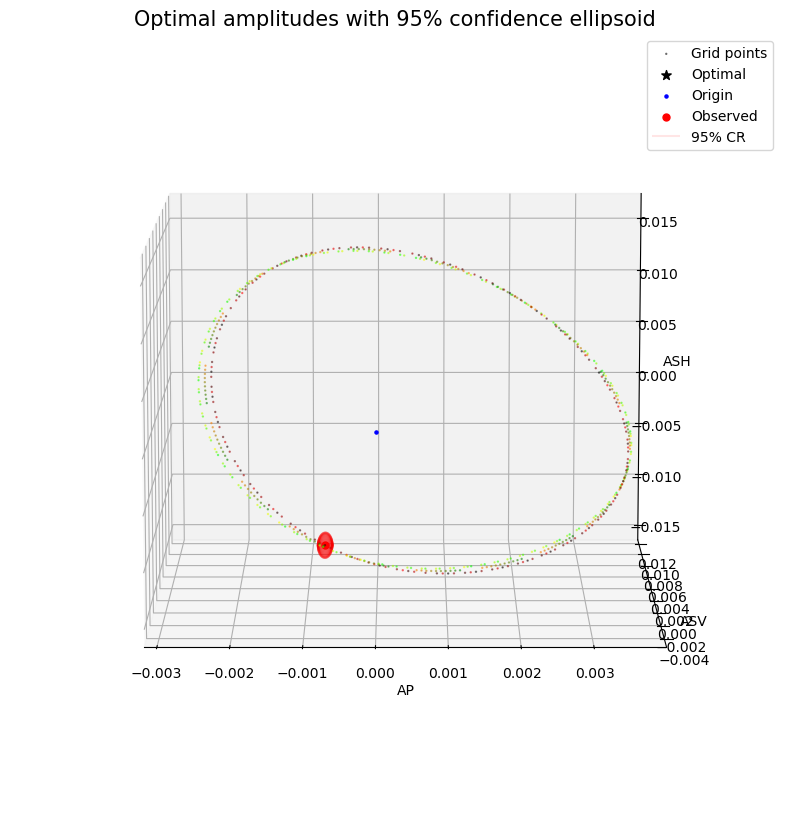

In [195]:
# RGB = azimuth, takeoff, takeoff
importlib.reload(plots)
radiation_model_1.reset_grid_amplitudes()
dd = 1
ps_gap = takeoff_angles[1] - takeoff_angles[0]
radiation_model_1.set_grid_amplitudes(dd, random=False, fix_params=True,
                                        zne=False,
                                        extract_range=[takeoff_angles[0],takeoff_angles[1]+fn.eps],
                                        # extract_range=[0, 180-ps_gap],
                                        ps_gap=ps_gap)
plots.amplitudes(radiation_model_1, azim=-90, elev=10, s=50, alpha=1,
                 iterates=False, grid=True, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                  uncertainty=True, conf=0.95, grid_mask=[1,1,0]) # colors

In [196]:
# TODO: Aspect ratio... make axes equal!!!

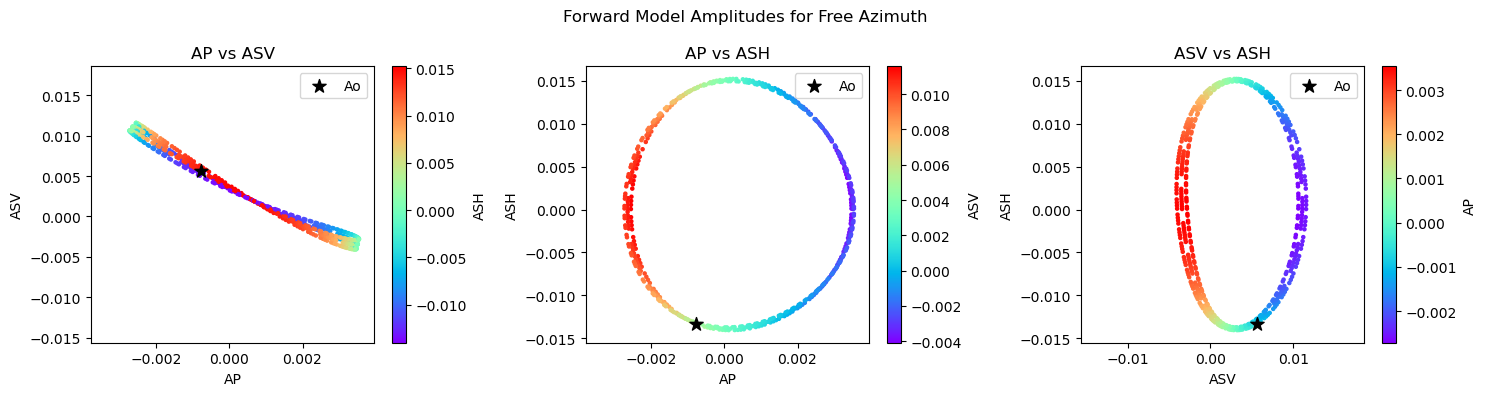

In [197]:
data = np.array(radiation_model_1.get_grid_amplitudes())
colors = np.array(radiation_model_1.get_grid_colors())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
padding = 0.05
range_0 = max_amps[0] - min_amps[0]
range_1 = max_amps[1] - min_amps[1]
range_2 = max_amps[2] - min_amps[2]

sc0 = axes[0].scatter(data[:,0], data[:,1], c=data[:,2], cmap='rainbow', s=5)
axes[0].set_xlabel('AP')
axes[0].set_ylabel('ASV')
axes[0].set_title('AP vs ASV')
cbar0 = plt.colorbar(sc0, ax=axes[0])
cbar0.set_label('ASH')
# set scale to min ... max amps
axes[0].set_xlim(min_amps[0] - padding*range_0, max_amps[0] + padding*range_0)
axes[0].set_ylim(min_amps[1] - padding*range_1, max_amps[1] + padding*range_1)
axes[0].scatter(model_Ao1[0], model_Ao1[1], color='k', s=100, marker='*', label='Ao')
axes[0].legend()

sc1 = axes[1].scatter(data[:,0], data[:,2], c=data[:,1], cmap='rainbow', s=5)
axes[1].set_xlabel('AP')
axes[1].set_ylabel('ASH')
axes[1].set_title('AP vs ASH')
cbar1 = plt.colorbar(sc1, ax=axes[1])
cbar1.set_label('ASV')
axes[1].set_xlim(min_amps[0] - padding*range_0, max_amps[0] + padding*range_0)
axes[1].set_ylim(min_amps[2] - padding*range_2, max_amps[2] + padding*range_2)
axes[1].scatter(model_Ao1[0], model_Ao1[2], color='k', s=100, marker='*', label='Ao')
axes[1].legend()

sc2 = axes[2].scatter(data[:,1], data[:,2], c=data[:,0], cmap='rainbow', s=5)
axes[2].set_xlabel('ASV')
axes[2].set_ylabel('ASH')
axes[2].set_title('ASV vs ASH')
cbar2 = plt.colorbar(sc2, ax=axes[2])
cbar2.set_label('AP')
axes[2].set_xlim(min_amps[1] - padding*range_1, max_amps[1] + padding*range_1)
axes[2].set_ylim(min_amps[2] - padding*range_2, max_amps[2] + padding*range_2)
axes[2].scatter(model_Ao1[1], model_Ao1[2], color='k', s=100, marker='*', label='Ao')
axes[2].legend()

plt.suptitle('Forward Model Amplitudes for Free Azimuth')
plt.tight_layout()
plt.show()

In [198]:
# remember to make a function for rotational information
# it's a step function

In [199]:
amps = radiation_model_1.get_grid_amplitudes()
amps = np.array(amps)
amps

# Z, N and E splits are 0, 1, 2 mod 3 indices respectively
Z_amps = amps[0::3]
N_amps = amps[1::3]
E_amps = amps[2::3]

new_matrix = np.column_stack((Z_amps, N_amps, E_amps))
print(new_matrix.shape)

# make line plots for [0-360] range of angles
angles = np.arange(0, 360, dd)

# make 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
amp_names = ['AP', 'ASV', 'ASH']

for i, name in enumerate(amp_names):
    # get the 0, 3, 6...
    Z_amp = Z_amps[:,i]
    N_amp = N_amps[:,i]
    E_amp = E_amps[:,i]
    axes[i].plot(angles, Z_amp, label='Z rotation', color='r')
    axes[i].plot(angles, N_amp, label='N rotation', color='g')
    axes[i].plot(angles, E_amp, label='E rotation', color='b')
    axes[i].set_ylabel(f'{amp_names[i]}')
    # horizontal line thru 0
    axes[i].axhline(0, color='k', linestyle='--', linewidth=1)
    axes[i].grid()
    axes[i].legend()

axes[-1].set_xlabel('Rotation angle (degrees)')
plt.suptitle('Amplitude vs Rotation Angle for Each Axis')
plt.tight_layout()
plt.show()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 182 and the array at index 2 has size 181